# Walk Forward Validation

## Objective

Evaluate robustness through annual retraining.

## Framework

Train: 2015-2020 → Test: 2021

Train: 2015-2021 → Test: 2022

Train: 2015-2022 → Test: 2023

Train: 2015-2023 → Test: 2024

Train: 2015-2024 → Test: 2025

In [2]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor

from scipy.stats import spearmanr

import matplotlib.pyplot as plt

In [3]:
feature_df = pd.read_csv(
    "feature_df_clean.csv",
    index_col=[0,1],
    parse_dates=[0]
)

print(feature_df.shape)

feature_df["rank_mom21"] = (
    feature_df.groupby(level=0)["mom21"]
    .rank(pct=True)
)

feature_df["rank_mom63"] = (
    feature_df.groupby(level=0)["mom63"]
    .rank(pct=True)
)

feature_df["rank_mom126"] = (
    feature_df.groupby(level=0)["mom126"]
    .rank(pct=True)
)

feature_df["rank_vol21"] = (
    feature_df.groupby(level=0)["vol21"]
    .rank(pct=True)
)

feature_df["rank_vol63"] = (
    feature_df.groupby(level=0)["vol63"]
    .rank(pct=True)
)

feature_df["rank_rsi14"] = (
    feature_df.groupby(level=0)["rsi14"]
    .rank(pct=True)
)

daily_mean_return = (
    feature_df.groupby(level=0)["future_return"]
    .transform("mean")
)

feature_df["future_relative_return"] = (
    feature_df["future_return"]
    -
    daily_mean_return
)

print(feature_df.columns)

(845236, 11)
Index(['mom21', 'mom63', 'mom126', 'vol21', 'vol63', 'ema_distance',
       'ema_slope', 'rsi14', 'future_return', 'market_mom21', 'market_vol21',
       'rank_mom21', 'rank_mom63', 'rank_mom126', 'rank_vol21', 'rank_vol63',
       'rank_rsi14', 'future_relative_return'],
      dtype='str')


In [4]:
features = [

    "mom21",
    "mom63",
    "mom126",

    "vol21",
    "vol63",

    "ema_distance",
    "ema_slope",

    "rsi14",

    "rank_mom21",
    "rank_mom63",
    "rank_mom126",

    "rank_vol21",
    "rank_vol63",

    "rank_rsi14"
]

In [5]:
test_years = [

    2021,
    2022,
    2023,
    2024,
    2025
]

In [6]:
all_predictions = []

for year in test_years:

    print(
        f"Testing {year}"
    )

    train = feature_df.loc[
        feature_df.index.get_level_values(0).year
        < year
    ]

    test = feature_df.loc[
        feature_df.index.get_level_values(0).year
        == year
    ]

    X_train = train[features]

    y_train = train[
        "future_relative_return"
    ]

    X_test = test[features]

    model = RandomForestRegressor(

        n_estimators=300,

        max_depth=10,

        min_samples_leaf=25,

        random_state=42,

        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    test = test.copy()

    test["prediction"] = (
        model.predict(X_test)
    )

    all_predictions.append(
        test
    )

Testing 2021
Testing 2022
Testing 2023
Testing 2024
Testing 2025


In [7]:
walkforward = pd.concat(
    all_predictions
)

print(
    walkforward.shape
)

(403361, 19)


In [8]:
daily_ic = []

for date, group in walkforward.groupby(
    level=0
):

    ic = spearmanr(

        group["prediction"],

        group[
            "future_relative_return"
        ]

    )[0]

    daily_ic.append(ic)

print(
    "Walk Forward Rank IC:",
    np.nanmean(daily_ic)
)

Walk Forward Rank IC: 0.018968103747823567


In [9]:
yearly_ic = {}

for year in test_years:

    temp = walkforward.loc[
        walkforward.index
        .get_level_values(0)
        .year == year
    ]

    year_ics = []

    for date, group in temp.groupby(
        level=0
    ):

        ic = spearmanr(

            group["prediction"],

            group[
                "future_relative_return"
            ]

        )[0]

        year_ics.append(ic)

    yearly_ic[year] = np.nanmean(
        year_ics
    )

pd.Series(
    yearly_ic
)

2021    0.036288
2022    0.007797
2023    0.059845
2024   -0.000707
2025   -0.010416
dtype: float64

In [10]:
rebalance_dates = (
    walkforward.index
    .get_level_values(0)
    .unique()[::21]
)

returns = []

for date in rebalance_dates:

    group = walkforward.loc[date]

    top20 = (
        group
        .nlargest(
            20,
            "prediction"
        )
    )

    returns.append(

        top20[
            "future_return"
        ].mean()

    )

returns = pd.Series(
    returns,
    index=rebalance_dates
)

In [11]:
def performance_stats(
    returns
):

    equity = (
        1 +
        returns
    ).cumprod()

    total_return = (
        equity.iloc[-1]
        - 1
    )

    years = (
        equity.index[-1]
        -
        equity.index[0]
    ).days / 365.25

    cagr = (
        equity.iloc[-1]
        **
        (1 / years)
        - 1
    )

   

    sharpe = (
    returns.mean()
    /
    returns.std()
    *
    np.sqrt(252/21)
    )

    drawdown = (
        equity
        /
        equity.cummax()
        - 1
    )

    max_dd = drawdown.min()

    return pd.Series({

        "Total Return":
            total_return,

        "CAGR":
            cagr,

        "Sharpe":
            sharpe,

        "Max DD":
            max_dd

    })

In [12]:
performance_stats(
    returns
)

Total Return    4.529730
CAGR            0.423185
Sharpe          1.534369
Max DD         -0.249890
dtype: float64

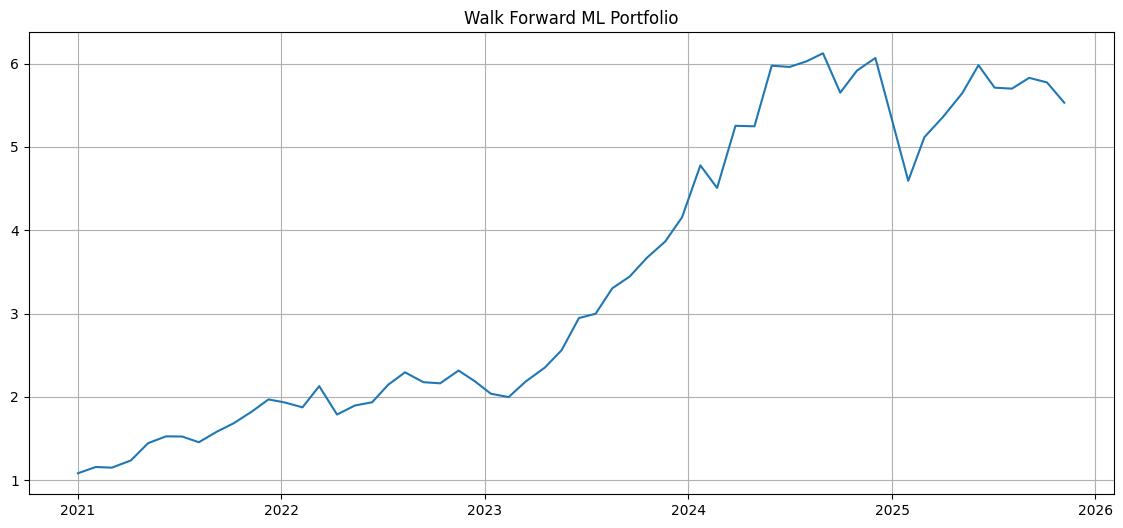

In [13]:
equity = (
    1 +
    returns
).cumprod()

plt.figure(
    figsize=(14,6)
)

plt.plot(
    equity
)

plt.title(
    "Walk Forward ML Portfolio"
)

plt.grid(True)

plt.show()

In [14]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=equity.index,
        y=equity.values,
        name="Walk Forward"
    )
)

fig.update_layout(
    title="Walk Forward Equity Curve",
    hovermode="x unified"
)

fig.write_html(
    "walk_forward_equity_curve.html"
)

fig.show()

In [15]:
strategy_summary = pd.DataFrame({

    "Metric":[
        "Total Return",
        "CAGR",
        "Sharpe",
        "Max DD"
    ],

    "Value":[
        4.5297,
        0.4232,
        1.5344,
        -0.2499
    ]

})

strategy_summary.to_csv(
    "strategy_summary.csv",
    index=False
)

pd.Series(
    yearly_ic
).to_csv(
    "yearly_rank_ic.csv"
)